<h1><center>Laboratorio 8: Predicciones y Recomendaciones 🔮🪄 </center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Valentina Abello
- Nombre de alumno 2: Renato Pino

### **Link de repositorio de GitHub:** [Repositorio](https://github.com/Renato-98/MDS7202-1)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/Lab_progra_DS/Lab_8/' # Ajustar al path propio
except:
    print('Ignorando conexión drive-colab')

Mounted at /content/drive


In [ ]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [ ]:
#Codigo Aqui

# Cargar los datos históricos
df = pd.read_csv(path+'energia_homero.csv')

#Transformar columna 'date' a formato 'datetime'
df['date'] = pd.to_datetime(df['date'])

# df.shape # (1498, 2)
df.head()

,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195


In [ ]:
# Visualizar el consumo de energía en la casa de Homero mediante la librería plotly

fig = px.line(df, x='date', y='Energy_kWh', title='Consumo de energía en la casa de Homero')
fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [ ]:
#CODIGO AQUI
# 0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29`
#y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
df['set'] = np.where(df['date'] <= '2020-02-29', 'train', 'test')
train = df[df['set'] == 'train'].copy()
test = df[df['set'] == 'test'].copy()

target = 'Energy_kWh'

X_train = train.drop(columns = ['set'])
y_train = train[target].copy()

X_test = test.drop(columns = ['set'])
y_test = test[target].copy()

###
print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de prueba:', X_test.shape)

X_train.head()

Tamaño del conjunto de entrenamiento: (1369, 2)
Tamaño del conjunto de prueba: (129, 2)


,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195


In [ ]:
# 1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]

# Utilizando la clase defina en clases
from sklearn.base import BaseEstimator, TransformerMixin

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):

        self.init_date = None

    def fit(self, X, y=None):

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

        return self

    def transform(self, X):

        X = X.copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        return X[['trend']]

    def fit_transform(self, X, y=None):

        X = X.copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        return X[['trend']]

# transformer = TimeTransformer()
# transformer.fit_transform(X_train) # notar que sólo usa la variable "date"

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline_trend = Pipeline([
    ('time_features', TimeTransformer()),
    ('ols', LinearRegression())
])

In [ ]:
# 2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo).
pipeline_trend.fit(X_train, y_train)
train_pred = pipeline_trend.predict(X_train)
test_pred = pipeline_trend.predict(X_test)

y_pred = np.concatenate([train_pred, test_pred])

y_pred.shape

# Luego grafique las predicciones
fig = px.line(df, x='date', y='Energy_kWh', title='Consumo de energía en la casa de Homero')
fig.add_scatter(x=df['date'], y=y_pred, mode='lines', name='Predicciones')
fig.show()

# Calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print('MAE en el conjunto de entrenamiento:', train_mae)
print('MAE en el conjunto de prueba:', test_mae)

MAE en el conjunto de entrenamiento: 10.568154088025606
MAE en el conjunto de prueba: 8.655813997873521


In [ ]:
# 3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
error_train = y_train - train_pred
error_test = y_test - test_pred
error = pd.concat([error_train, error_test])

fig = px.line(x = df['date'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set'])
fig.show()

Del gráfico se puede observar un comportamiento repetitivo a lo largo del tiempo (especialmente en el conjunto de entrenamiento), obsevando periodos con picos que aparecen cada cierto intervalo de tiempo, por lo que sí podría considerarse que existe un comportamiento estacional en la serie.

In [ ]:
# 4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier
# y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`.
# Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
from sklearn.base import BaseEstimator, TransformerMixin

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, n = 4, p = 365):

        self.init_date = None
        self.n = n
        self.p = p

    def fit(self, X, y=None):

        '''
        Realiza el fit sobre los datos --> guarda la fecha de inicio de entrenamiento.
        '''

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

    def transform(self, X):

        '''
        Realiza el transform sobre el conjunto X, retornando los términos de fourier.
        '''

        X = X[['date']].copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.index[-1] # last date of X
        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def fit_transform(self, X, y=None):

        '''
        implementa el método fit y transform a la vez.
        '''

        X = X[['date']].copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def get_fourier_terms(self, serie, n, p):

        '''
        Obtiene los términos de fourier de una serie
        '''

        terms = []
        for i in range(1, n + 1):
            sine_term = np.sin(2 * np.pi * i * serie / p)
            cosine_term = np.cos(2 * np.pi * i * serie / p)
            terms.extend([sine_term, cosine_term])

        fourier = np.column_stack(terms)
        fourier = pd.DataFrame(fourier, columns = [f'fourier_{i}' for i in range(n * 2)], index = serie.index) # este paso es opcional

        return fourier

# transformer = TimeTransformer(n = 4, p = 365)
# transformer.fit_transform(X_train) # notar que sólo usa la variable "date"

pipeline_seasonal = Pipeline([
    ('time_features', TimeTransformer()),
    ('ols', LinearRegression())
])

# (n = 4, p = 365)

# 5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo.
pipeline_seasonal.fit(X_train, y_train)
train_pred = pipeline_seasonal.predict(X_train)
test_pred = pipeline_seasonal.predict(X_test)

y_pred = np.concatenate([train_pred, test_pred])
# Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
fig = px.line(df, x='date', y='Energy_kWh', title='Consumo de energía en la casa de Homero')
fig.add_scatter(x=df['date'], y=y_pred, mode='lines', name='Predicciones')
fig.show()

In [ ]:
# 6. Vuelva a graficar el error y comente los resultados. [1 punto]
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print('MAE en el conjunto de entrenamiento:', train_mae)
print('MAE en el conjunto de prueba:', test_mae)

error_train = y_train - train_pred
error_test = y_test - test_pred
error = pd.concat([error_train, error_test])

fig = px.line(x = df['date'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set']) #este se ve mejor
fig.show()

MAE en el conjunto de entrenamiento: 5.345588745161719
MAE en el conjunto de prueba: 4.457477760410813


De acuerdo a los valores obtenidos del MAE y el gráfico de errores, luego de ajustar el modelo con los términos de Fourier, se observa una menor disperción en comparación con el gráfico anterior, por lo que el modelo tendría mejor capacidad para ajustarse a la serie.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [ ]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

**Respuesta:**

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/feucoimp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/egght_vx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75033', 'data', 'file=/tmp/tmpfs0pa3oz/feucoimp.json', 'init=/tmp/tmpfs0pa3oz/egght_vx.json', 'output', 'file=/tmp/tmpfs0pa3oz/prophet_model14ork_r5/prophet_model-20241021005026.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:50:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:50:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


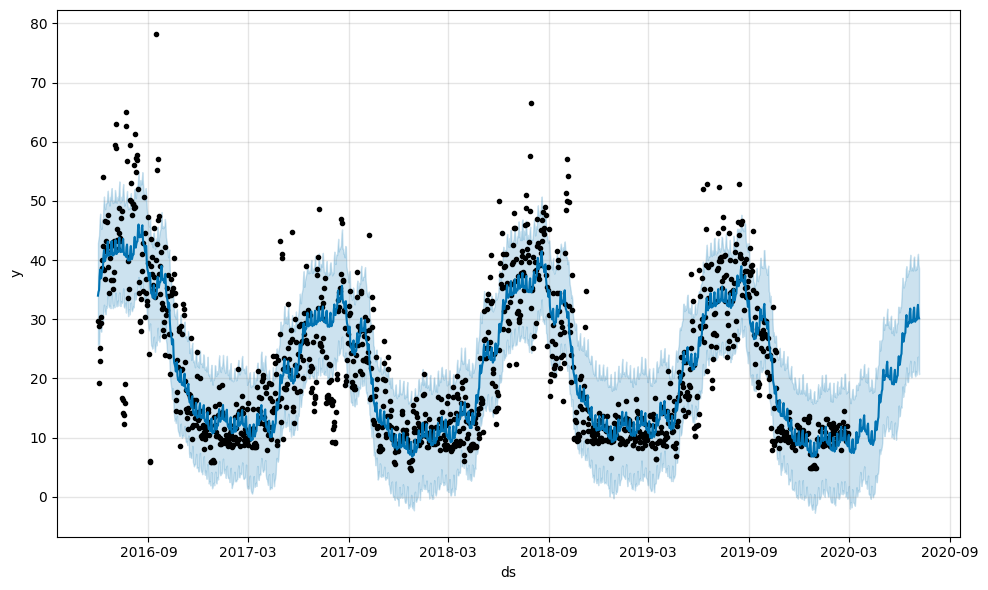

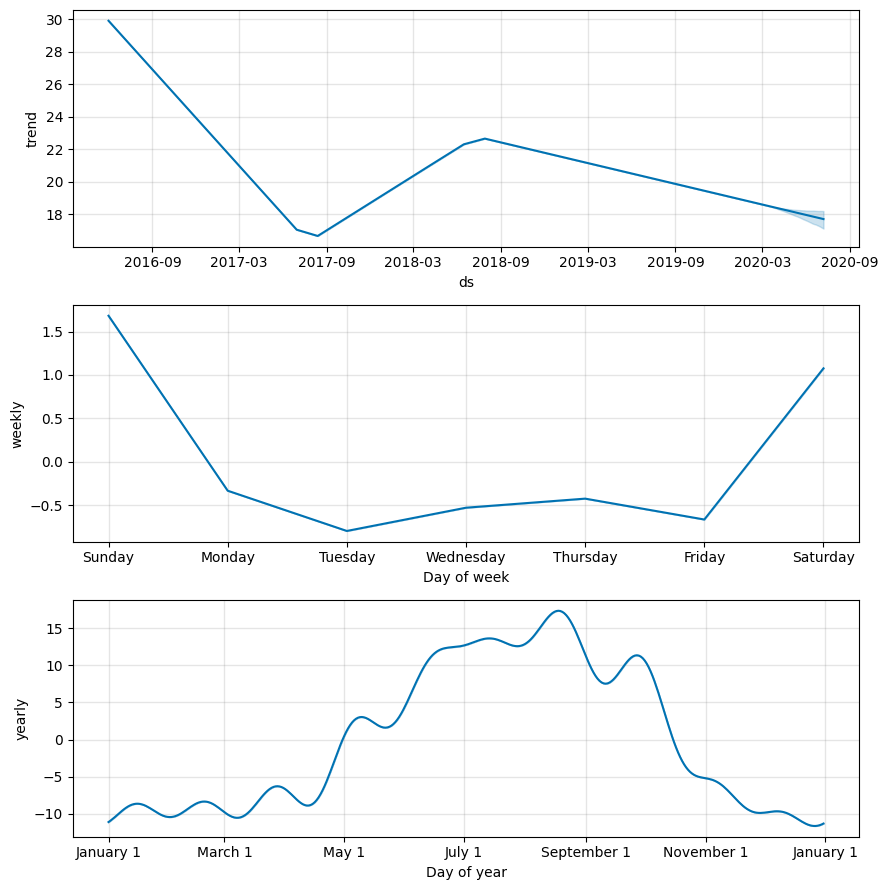

In [ ]:
#CODIGO AQUI
# 1. Instale y cargue Prophet a su entorno de trabajo.
# Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
train = X_train.rename(columns = {'date': 'ds', 'Energy_kWh': 'y'})
test = X_test.rename(columns = {'date': 'ds', 'Energy_kWh': 'y'})

# 2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento.
model = Prophet()
model.fit(train)

# Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. [2 puntos]
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)
forecast_pred = forecast.loc[forecast['ds'].isin(test['ds'])].reset_index(drop=True)

# 3. Grafique las predicciones y las componentes del modelo Prophet. Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
fig = model.plot(forecast)
fig.show()

fig = model.plot_components(forecast)
fig.show()

In [ ]:
# 4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
mae_train = mean_absolute_error(train['y'], forecast[forecast['ds'].isin(train['ds'])]['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_pred['yhat'])

print('MAE en el conjunto de entrenamiento:', mae_train)
print('MAE en el conjunto de prueba:', mae_test)

# 5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]
error_train = train['y'].reset_index(drop=True) - forecast[forecast['ds'].isin(train['ds'])]['yhat'].reset_index(drop=True)
error_test = test['y'].reset_index(drop=True) - forecast_pred['yhat'].reset_index(drop=True)

error = pd.concat([error_train, error_test]).reset_index(drop=True)

fig = px.line(x = df['date'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set'])
fig.show()

MAE en el conjunto de entrenamiento: 4.817481017717443
MAE en el conjunto de prueba: 4.921079315201517


Del gráfico se siguen observando un comportamiento repetitivo de los errores y los picos antes también vistos en los otros gráficos. Por lo que podríamos concluír que sí existe un comportamiento estacional en la serie.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

In [ ]:
#CODIGO AQUI

# 0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`.
df2 = pd.read_csv(path + 'datos_frink.csv')
df2 = df2.rename(columns = {'date': 'ds'})
df2['ds'] = pd.to_datetime(df2['ds'])
df2.dtypes
# Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
#train = X_train.rename(columns = {'date': 'ds', 'Energy_kWh': 'y'})
#test = X_test.rename(columns = {'date': 'ds', 'Energy_kWh': 'y'})

train = train.merge(df2, on = 'ds', how = 'left')
test = test.merge(df2, on = 'ds', how = 'left')

train.head()

,ds,y,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min
0,2016-06-01,29.691,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7
1,2016-06-02,28.789,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7
2,2016-06-03,19.247,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7
3,2016-06-04,22.883,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7
4,2016-06-05,25.195,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7


In [ ]:
print(train[['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']].isnull().sum())
print(test[['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']].isnull().sum())

Temp_avg     0
Dew_avg      0
Hum_avg      0
Wind_avg     0
Press_avg    0
dtype: int64
Temp_avg     0
Dew_avg      0
Hum_avg      0
Wind_avg     0
Press_avg    0
dtype: int64


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/4or2id4t.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/wtfc6vib.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49762', 'data', 'file=/tmp/tmpfs0pa3oz/4or2id4t.json', 'init=/tmp/tmpfs0pa3oz/wtfc6vib.json', 'output', 'file=/tmp/tmpfs0pa3oz/prophet_model3ig090f_/prophet_model-20241021005235.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:52:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:52:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


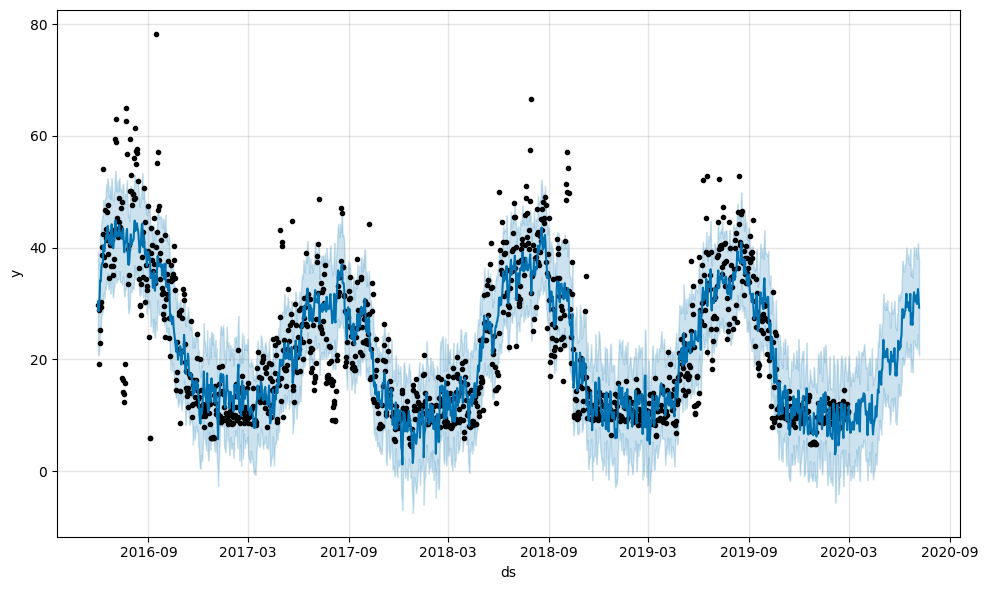

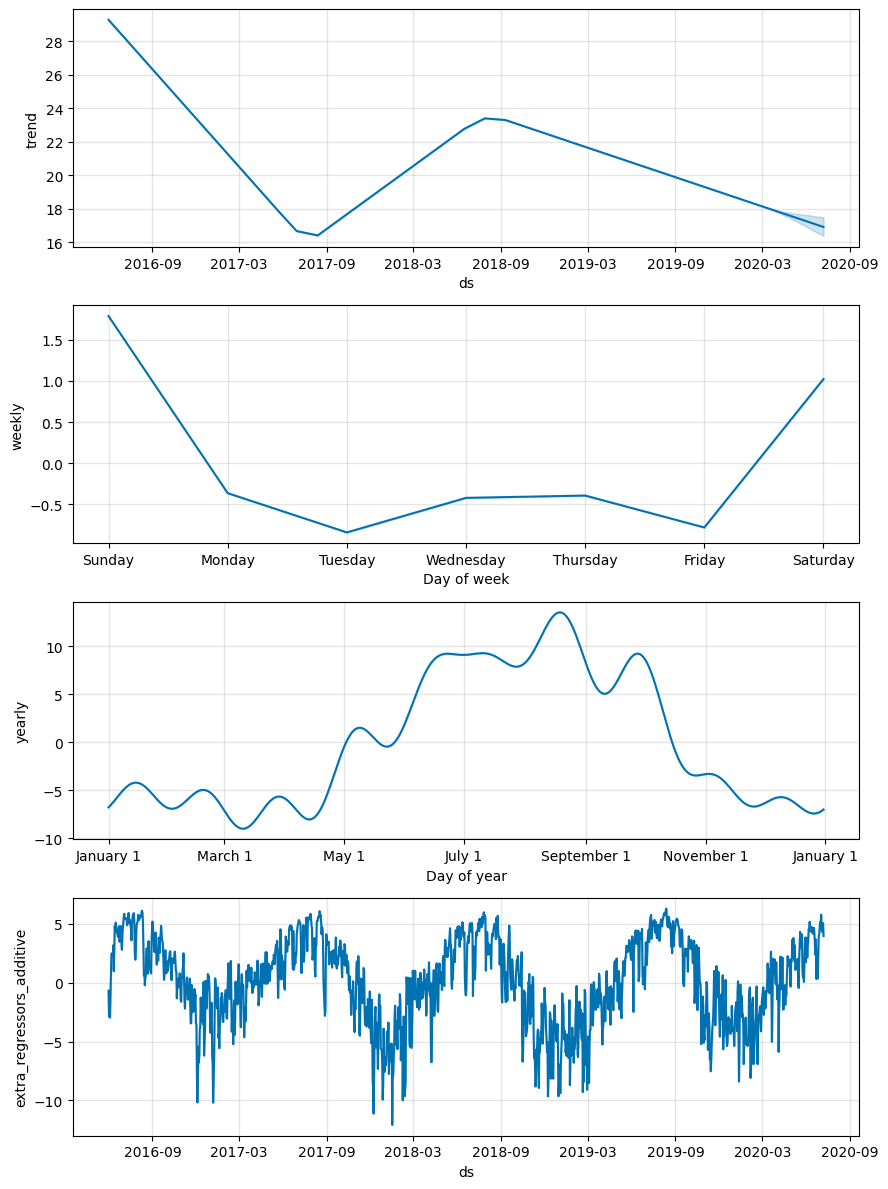

In [ ]:
# 1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
model = Prophet()
for feature in ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']:
    model.add_regressor(feature)

model.fit(train)

future = model.make_future_dataframe(periods=len(test))

# Agregar las variables exógenas al dataframe de predicciones
for feature in ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']:
    future[feature] = pd.concat([train[feature], test[feature]]).reset_index(drop=True)

forecast = model.predict(future)
forecast_pred = forecast.loc[forecast['ds'].isin(test['ds'])].reset_index(drop=True)


# 2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
fig = model.plot(forecast)
fig.show()

fig = model.plot_components(forecast)
fig.show()

In [ ]:
# 3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
mae_train = mean_absolute_error(train['y'], forecast[forecast['ds'].isin(train['ds'])]['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_pred['yhat'])

print('MAE en el conjunto de entrenamiento:', mae_train)
print('MAE en el conjunto de prueba:', mae_test)

error_train = train['y'].reset_index(drop=True) - forecast[forecast['ds'].isin(train['ds'])]['yhat'].reset_index(drop=True)
error_test = test['y'].reset_index(drop=True) - forecast_pred['yhat'].reset_index(drop=True)
error = pd.concat([error_train, error_test]).reset_index(drop=True)

# 4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]
fig = px.line(x = df2['ds'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set'])
fig.show()

MAE en el conjunto de entrenamiento: 4.715355995802214
MAE en el conjunto de prueba: 4.516350770821477


3. Los valores del MAE disminuyeron en ambos conjuntos en comparación a los modelos hechos anteriormente, que nos inidicaría que incluir estas variables exógenas al modelo podría capturar mejor la estacionalidad de la serie.

4. Del gráfico podemos concluir que sigue existiendo un comportamiento estacional en la serie. Dado que el valor del error disminuyó, podríamos concluir que incluír estas variables sí influyen al modelo y estarían afectando al comportamiento de la demanda de energía.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

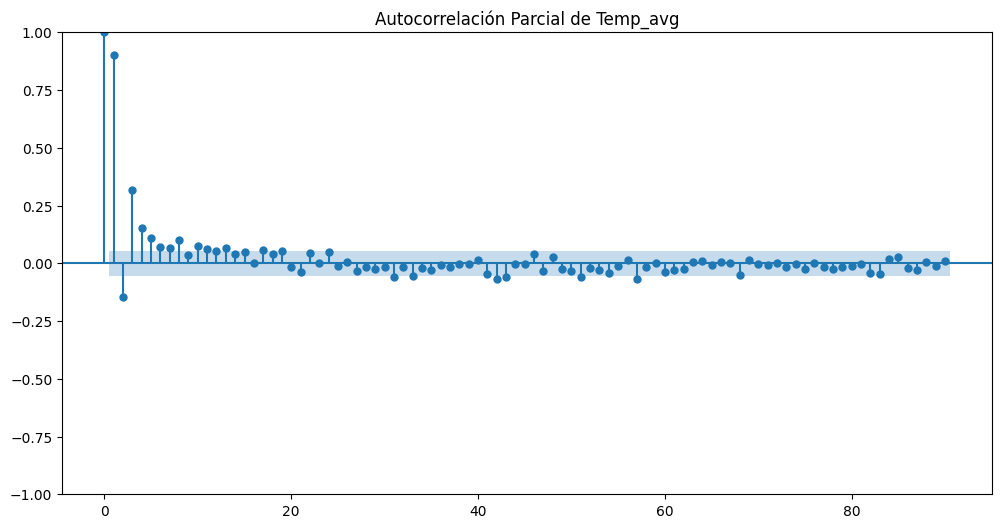

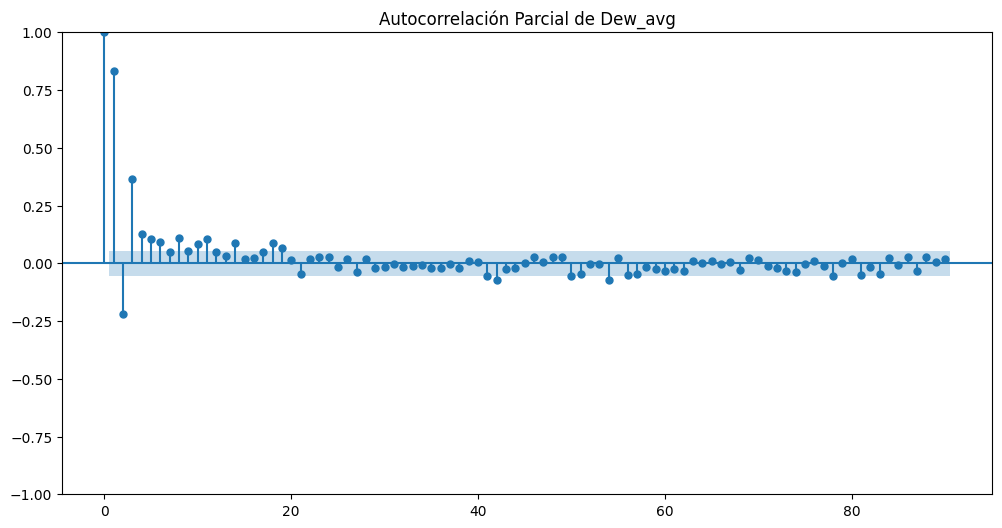

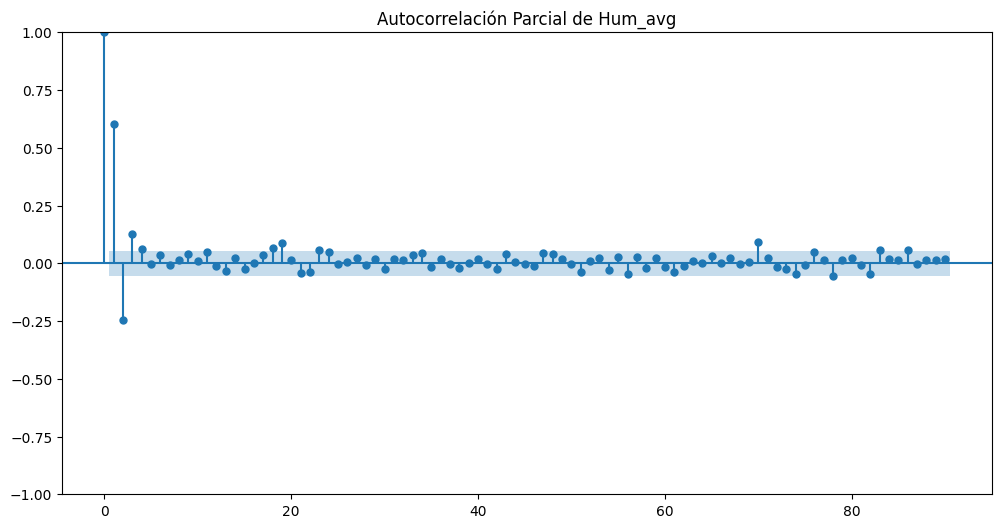

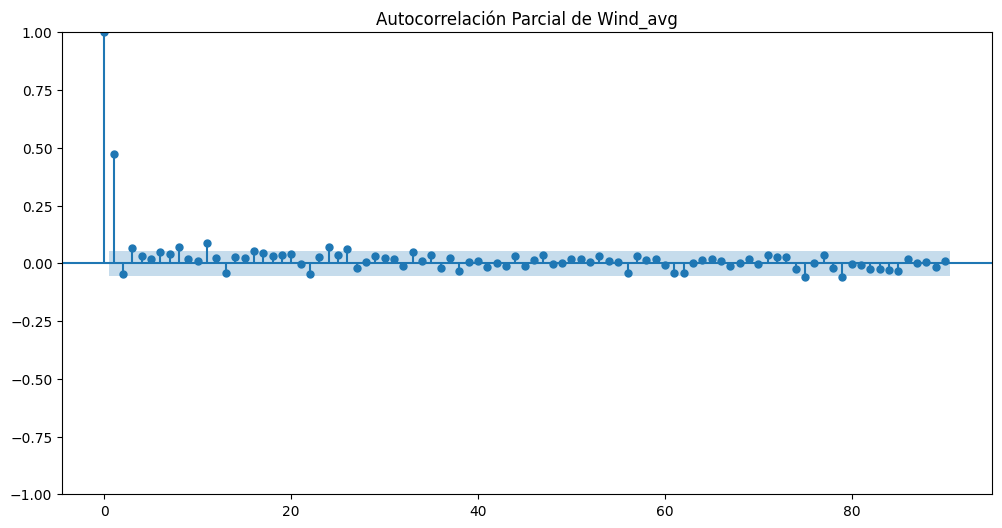

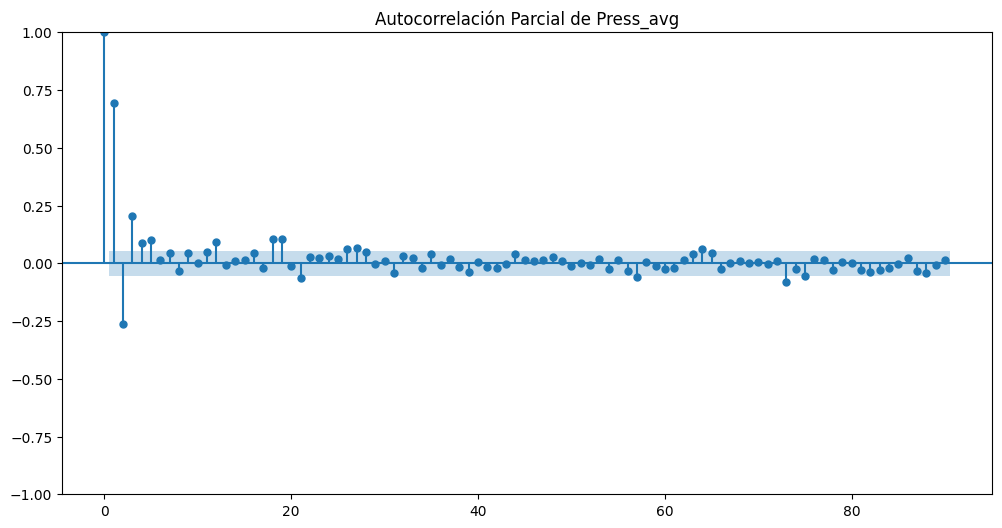

In [ ]:
#CODIGO AQUI
# 1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

variables_exogenas = ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']

# Iteramos sobre cada variable exógena para calcular su PACF
for feature in variables_exogenas:
    fig, aux = plt.subplots(figsize=(12,6))
    plot_pacf(train[feature], lags=90, alpha=0.05, ax=aux)  # Calcular PACF con 30 rezagos
    plt.title(f'Autocorrelación Parcial de {feature}')
    plt.show()

De los gráficos se puede concluir lo siguiente para las variables exógenas seleccionadas ('`Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg'` y `'Press_avg'`), los primeros dos rezagos tienen una fuerte dependencia con la variable objetivo. Añadir más rezagos pareciera no ser útil, dado que no pareciera existir una correlación muy alta.

In [ ]:
# 2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]
def get_lags(X):
    '''
    Retorna variables temporales basadas en lags.
    '''

    lag_features = pd.DataFrame(index=X.index)
    lag_features['lag_1'] = X.shift(1)
    lag_features['lag_2'] = X.shift(2)

    return lag_features[['lag_1', 'lag_2']]

train_lags = pd.DataFrame(index=train.index)
test_lags = pd.DataFrame(index=test.index)

# Iteraramos sobre cada variable exógena
for feature in variables_exogenas:
    # train
    train_lagged = get_lags(train[feature])
    train_lags[f'{feature}_lag_1'] = train_lagged['lag_1']
    train_lags[f'{feature}_lag_2'] = train_lagged['lag_2']

    # test
    test_lagged = get_lags(test[feature])
    test_lags[f'{feature}_lag_1'] = test_lagged['lag_1']
    test_lags[f'{feature}_lag_2'] = test_lagged['lag_2']

train = pd.concat([train, train_lags], axis=1)
test = pd.concat([test, test_lags], axis=1)

train.head()

,ds,y,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,...,Temp_avg_lag_1,Temp_avg_lag_2,Dew_avg_lag_1,Dew_avg_lag_2,Hum_avg_lag_1,Hum_avg_lag_2,Wind_avg_lag_1,Wind_avg_lag_2,Press_avg_lag_1,Press_avg_lag_2
0,2016-06-01,29.691,85,74.8,68,74,71.4,66,100,89.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-06-02,28.789,76,71.2,66,74,70.3,66,100,96.8,...,74.8,NaN,71.4,NaN,89.4,NaN,9.5,NaN,29.8,NaN
2,2016-06-03,19.247,79,72.1,68,72,70.0,68,100,93.6,...,71.2,74.8,70.3,71.4,96.8,89.4,7.8,9.5,29.8,29.8
3,2016-06-04,22.883,76,71.2,69,73,70.0,66,100,96.1,...,72.1,71.2,70.0,70.3,93.6,96.8,4.7,7.8,29.8,29.8
4,2016-06-05,25.195,82,73.8,68,72,70.0,68,100,88.7,...,71.2,72.1,70.0,70.0,96.1,93.6,7.0,4.7,29.7,29.8


In [ ]:
# 3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]
train = train.fillna(train.mean())
test = test.fillna(test.mean())

# Verificaremos si quedan valores nulos
print(train.isnull().sum())
print(test.isnull().sum())

ds                 0
y                  0
Temp_max           0
Temp_avg           0
Temp_min           0
Dew_max            0
Dew_avg            0
Dew_min            0
Hum_max            0
Hum_avg            0
Hum_min            0
Wind_max           0
Wind_avg           0
Wind_min           0
Press_max          0
Press_avg          0
Press_min          0
Temp_avg_lag_1     0
Temp_avg_lag_2     0
Dew_avg_lag_1      0
Dew_avg_lag_2      0
Hum_avg_lag_1      0
Hum_avg_lag_2      0
Wind_avg_lag_1     0
Wind_avg_lag_2     0
Press_avg_lag_1    0
Press_avg_lag_2    0
dtype: int64
ds                 0
y                  0
Temp_max           0
Temp_avg           0
Temp_min           0
Dew_max            0
Dew_avg            0
Dew_min            0
Hum_max            0
Hum_avg            0
Hum_min            0
Wind_max           0
Wind_avg           0
Wind_min           0
Press_max          0
Press_avg          0
Press_min          0
Temp_avg_lag_1     0
Temp_avg_lag_2     0
Dew_avg_lag_1      0


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/psdh3ap7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfs0pa3oz/pvwhs72a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58939', 'data', 'file=/tmp/tmpfs0pa3oz/psdh3ap7.json', 'init=/tmp/tmpfs0pa3oz/pvwhs72a.json', 'output', 'file=/tmp/tmpfs0pa3oz/prophet_modelwti6uco5/prophet_model-20241021010231.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:02:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:02:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


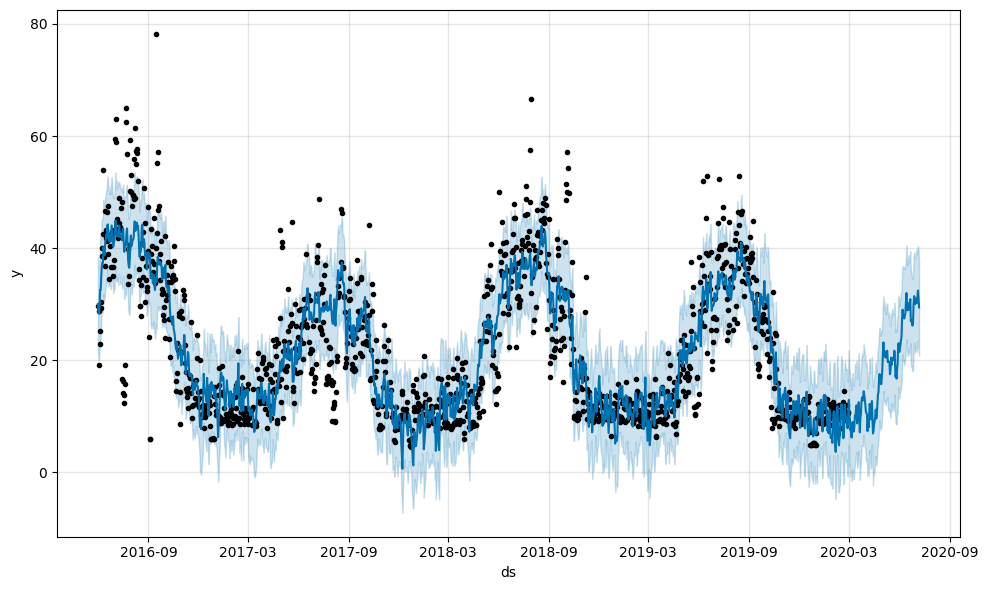

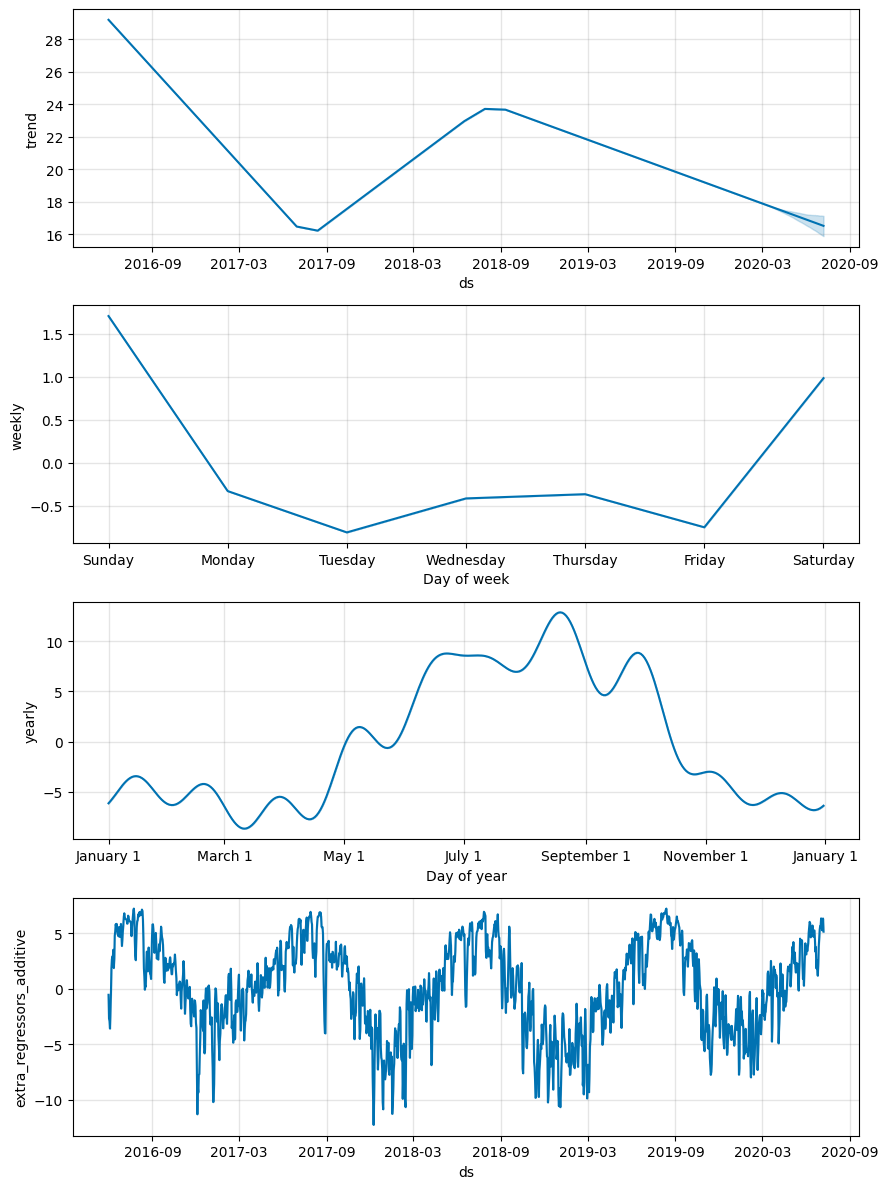

In [ ]:
# 4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]
model = Prophet()

for feature in variables_exogenas:
    model.add_regressor(feature)
    for lag in ['lag_1', 'lag_2']:
        model.add_regressor(f'{feature}_{lag}')

model.fit(train)

future = model.make_future_dataframe(periods=len(test))

for feature in variables_exogenas:
    future[feature] = pd.concat([train[feature], test[feature]]).reset_index(drop=True)
    for lag in ['lag_1', 'lag_2']:
        future[f'{feature}_{lag}'] = pd.concat([train[f'{feature}_{lag}'], test[f'{feature}_{lag}']]).reset_index(drop=True)

forecast = model.predict(future)
forecast_pred = forecast.loc[forecast['ds'].isin(test['ds'])].reset_index(drop=True)

# 5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
fig = model.plot(forecast)
fig.show()

fig = model.plot_components(forecast)
fig.show()

In [ ]:
# 6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
mae_train = mean_absolute_error(train['y'], forecast[forecast['ds'].isin(train['ds'])]['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_pred['yhat'])

print('MAE en el conjunto de entrenamiento:', mae_train)
print('MAE en el conjunto de prueba:', mae_test)

error_train = train['y'].reset_index(drop=True) - forecast[forecast['ds'].isin(train['ds'])]['yhat'].reset_index(drop=True)
error_test = test['y'].reset_index(drop=True) - forecast_pred['yhat'].reset_index(drop=True)
error = pd.concat([error_train, error_test]).reset_index(drop=True)

#7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]
fig = px.line(x = df2['ds'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set'])
fig.show()

MAE en el conjunto de entrenamiento: 4.679498280731948
MAE en el conjunto de prueba: 4.505330568714861


6. Se observa una pequeña disminución en los valores del MAE luego de incluir los lags a las variables exógenas seleccionadas, indicando una pequeña mejora en comparación con los modelos anteriores.

7. El gráfico del error sigue un patrón muy similar a los anteriores, inidcando que la inclusión de lags no cambia drásticamente el comportamiento del modelo.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [ ]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [ ]:
#CODIGO AQUI
# 1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9, 1.0]
}

tuning_results, best_params = optimize_prophet(train, test, variables_exogenas, param_grid)

print(tuning_results.head())
print('Mejores parámetros: ', best_params)

Tuning Prophet parameters: 100%|██████████| 72/72 [00:55<00:00,  1.29it/s]

    changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
2                     0.001                     0.01         additive   
1                     0.001                     0.01         additive   
66                    0.500                     1.00         additive   
27                    0.010                     0.10   multiplicative   
28                    0.010                     0.10   multiplicative   

    changepoint_range      MAEs  
2                 1.0  3.962829  
1                 0.9  3.996766  
66                0.8  4.034457  
27                0.8  4.036455  
28                0.9  4.043569  
Mejores parámetros:  {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'additive', 'changepoint_range': 1.0}


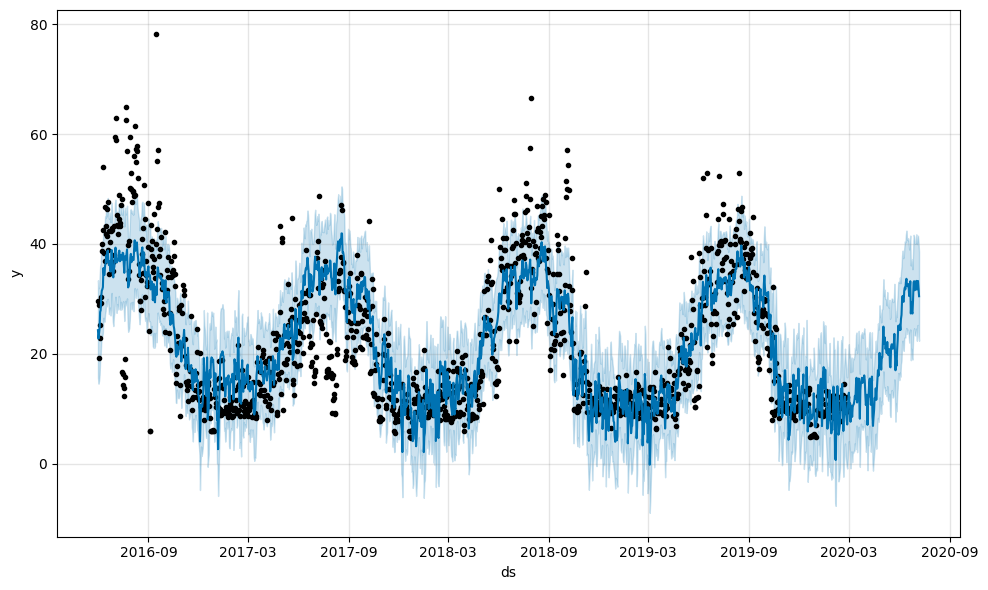

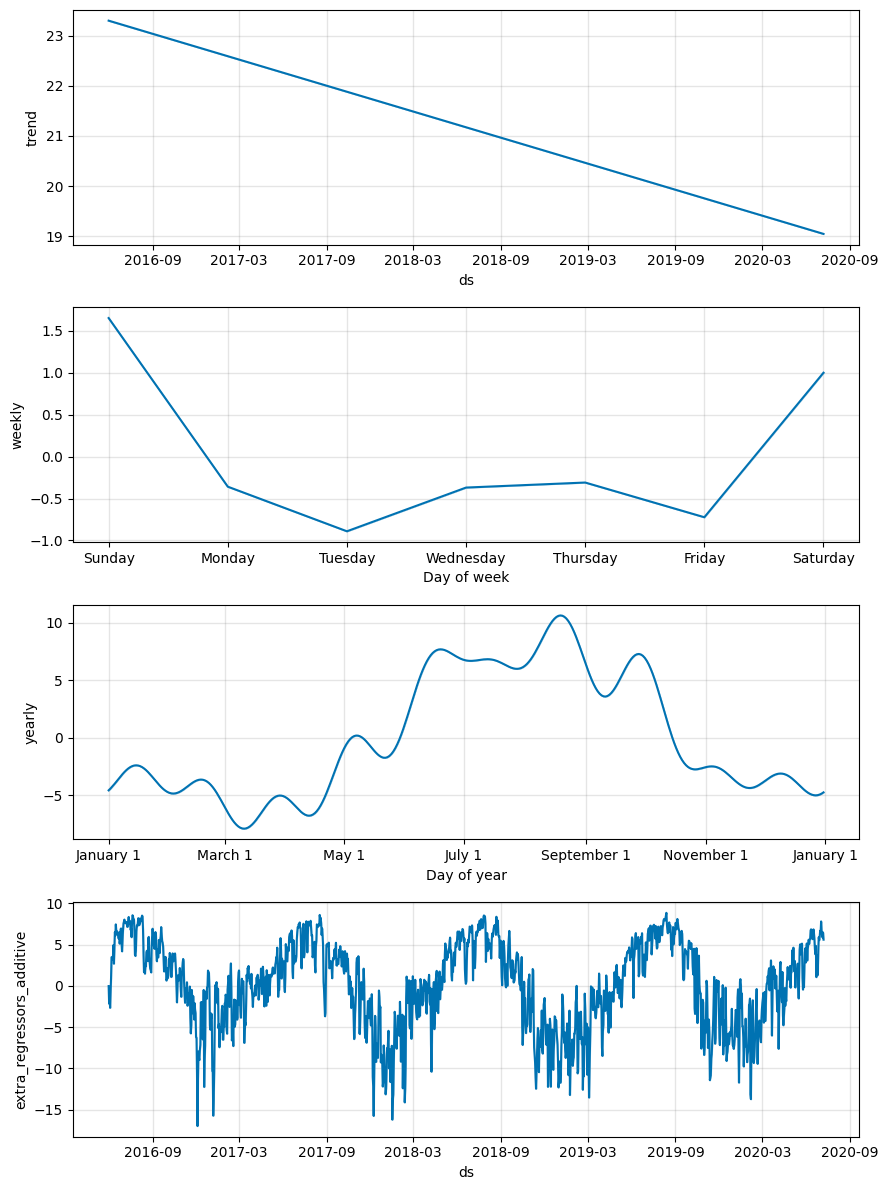

In [ ]:
# 2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
model = Prophet(**best_params)

for feature in variables_exogenas:
    model.add_regressor(feature)

model.fit(train)

future = model.make_future_dataframe(periods=len(test))

for feature in variables_exogenas:
    future[feature] = pd.concat([train[feature], test[feature]]).reset_index(drop=True)

forecast = model.predict(future)
forecast_pred = forecast.loc[forecast['ds'].isin(test['ds'])].reset_index(drop=True)

# 3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
fig = model.plot(forecast)
fig.show()

fig = model.plot_components(forecast)
fig.show()

In [ ]:
# 4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
mae_train = mean_absolute_error(train['y'], forecast[forecast['ds'].isin(train['ds'])]['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_pred['yhat'])

print('MAE en el conjunto de entrenamiento:', mae_train)
print('MAE en el conjunto de prueba:', mae_test)

error_train = train['y'].reset_index(drop=True) - forecast[forecast['ds'].isin(train['ds'])]['yhat'].reset_index(drop=True)
error_test = test['y'].reset_index(drop=True) - forecast_pred['yhat'].reset_index(drop=True)
error = pd.concat([error_train, error_test]).reset_index(drop=True)

# 5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]
fig = px.line(x = df2['ds'], y = error, title = 'Error en el conjunto de entrenamiento y prueba', color = df['set'])
fig.show()

MAE en el conjunto de entrenamiento: 5.417913311370737
MAE en el conjunto de prueba: 3.9628291458349953


El gráfico obtenido es similar a los anteriores, aun que con una pequeña dispersión distinta, que podría indicar una mejor predicción en el conjunto de prueba. De acuerdo a los valores obtenidos del MAE, en el conjunto de entrenamiento aumento ligeramente mientras que en el conjunto de prueba disminuyó, que podría indicar que el modelo reduce su error en las predicciones futuras.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp310-cp310-linux_x86_64.whl size=2357271 sha256=456e8fd321a43246466b231238fd07004f9cdfa67a3f44811a1e4ad99b34de1f
  Stored in directory: /root/.cache/pip/wheels/4b/3f/df/6acbf0a40397d9bf3ff97f582cc22fb9ce66adde75bc71fd54
Successfully built scikit-surprise


In [ ]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [ ]:
#CODIGO AQUI

# Cargar el dataset de cervezas
df_cervezas = pd.read_csv(path+'cervezas.csv')

In [ ]:
df_cervezas.head()

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [ ]:
# Exploración inicial
print(df_cervezas.info())  # Verificar tipos de datos y nulos
print('Estadísticas descriptivas: ')
print(df_cervezas.describe())  # Estadísticas descriptivas
print('')

# Obtener el numero de usuarios unicos, productos y calificaciones
n_usuarios = df_cervezas['userId'].nunique()
n_productos = df_cervezas['beerName'].nunique()
n_calificaciones = df_cervezas['rating'].count()
print('')

# Imprimir los resultados
print(f"Número de usuarios: {n_usuarios}")
print(f"Número de productos (cervezas): {n_productos}")

print(f"Número de calificaciones: {n_calificaciones}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB
None
Estadísticas descriptivas: 
              userId         beerId         rating
count  295059.000000  295059.000000  295059.000000
mean     2201.510247   17498.665684       3.860367
std      4577.423286   19971.480254       0.702807
min         1.000000       5.000000       1.000000
25%       132.000000    1185.000000       3.500000
50%       293.000000    6314.000000       4.000000
75%      1141.000000   33639.000000       4.500000
max     27681.000000   75086.000000       5.000000


Número de usuarios: 706
Número de productos (c

In [ ]:
# En caso de que calificaciones faltantes se refiere a que cada usuario deberia de haber calificado todas las cervezas:

n_calificaciones_totales = n_usuarios * n_productos # Numero de todas la calificaciones posibles.
n_calificaciones_faltantes = n_calificaciones_totales - n_calificaciones # Numero de calificaciones faltantes.
print(f"Número de calificaciones faltantes: {n_calificaciones_faltantes}")

Número de calificaciones faltantes: 2309375


In [ ]:
df_cervezas.beerId.nunique()  == df_cervezas.beerName.nunique() # baia baia

False

<ipython-input-37-17821b33129e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=media_producto_nombre.index[:20], x=media_producto_nombre.values[:20], palette="viridis")


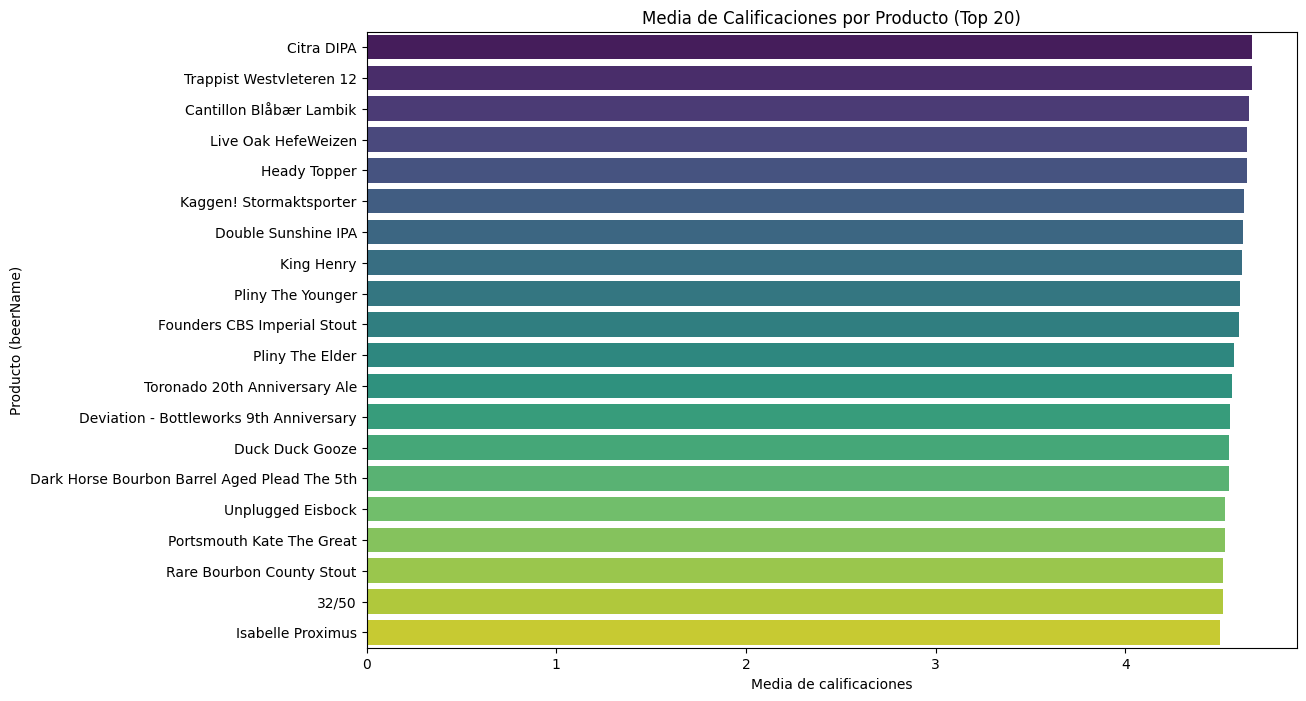

In [ ]:
# Calculamos la media de calificaciones por producto (beerName)
media_producto_nombre = df_cervezas.groupby('beerName')['rating'].mean().sort_values(ascending=False)

# Se Grafica la media de calificaciones por producto
plt.figure(figsize=(12, 8))
sns.barplot(y=media_producto_nombre.index[:20], x=media_producto_nombre.values[:20], palette="viridis")
plt.title('Media de Calificaciones por Producto (Top 20)')
plt.xlabel('Media de calificaciones')
plt.ylabel('Producto (beerName)')
plt.show()

1. ¿Cuántos usuarios hay en los datos? R: 706 usuarios

2. ¿Cuántos productos hay en los datos? R: 3689 cervezas. Aqui utilizamos la variable beerName en lugar de beerId porque habian cervezas duplicadas con IDs distindos. Por ejemplo, la cerveza "Chocolate Porter" aparecia dos veces con Ids 6499 y 10408.

3. ¿Cuántas calificaciones hay en los datos? R: 295059 calificaciones (igual al numero de filas)

4. ¿Cuántas calificaciones faltantes hay en los datos? R: No hay datos faltantes, pero en caso de que calificaciones faltantes se refiere a que cada usuario deberia de haber calificado todas las cervezas, faltarian 2309375 calificaciones.

5. ¿Cuál es la media de las calificaciones entregadas por los usuarios y cómo cambia a través de los productos? R: La media de rating de los productos entregadas por los usuarios es  de 3.860367. En cuanto a como varian por productos podemos ver el grafico de la media en rating de las top 20 cervezas arriba.

In [ ]:
#2.
# Agrupar los datos por userId y beerName y tomar el promedio de las calificaciones duplicadas
df_sin_duplicados = df_cervezas.groupby(['userId', 'beerName']).agg({'rating': 'mean'}).reset_index()

# Crear la matriz (usuario, producto)
user_product_matrix = df_sin_duplicados.pivot(index='userId', columns='beerName', values='rating')

user_product_matrix.head()

beerName,"""Shabadoo"" Black & Tan Ale",# 100,#9,'t Gaverhopke Extra,'t Smisje Calva Reserva,(512) Pecan Porter,10 Commandments,10 Squared Fish Tale Ale,10.0,1000 IBU,...,Žatec,§ucaba (Abacus),Édition 2005,Éphémère (Apple),Éphémère (Cassis / Black Currant),Éphémère (Cranberry),Équinoxe Du Printemps,Ølfabrikken Porter,Über Pils,ÜberSun (Imperial Summer Wheat Beer)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
user_product_matrix.shape

(706, 3689)

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero esta buscando nuevas cervezas para su consumo personal, donde usted pudo notar que Homero esta identificado como `userId = 100` en el dataset. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Homero (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [ ]:
#CODIGO AQUI

#1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos

# DataFrame con las características de las cervezas (sin duplicados y excluyendo las evaluaciones)
df_caracteristicas_cerveza = df_cervezas[['beerId', 'beerName', 'beerStyle']].drop_duplicates(subset='beerName')

df_caracteristicas_cerveza.head()

,beerId,beerName,beerStyle
0,995,Mai Bock,Maibock / Helles Bock
1,58695,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,4083,Stone Ruination IPA,American Double / Imperial IPA
3,40310,Noël Des Géants,Herbed / Spiced Beer
4,1904,Sierra Nevada Celebration Ale,American IPA


In [ ]:
assert df_caracteristicas_cerveza.shape == (3689, 3)

In [ ]:
df_caracteristicas_cerveza[df_caracteristicas_cerveza['beerName'] == 'Chocolate Porter']

,beerId,beerName,beerStyle
3301,6499,Chocolate Porter,American Porter


In [ ]:
#2. Implemente el método Bag of Words para procesar la columna beerStyle

# Configuración del CountVectorizer
vectorizer = CountVectorizer(stop_words='english', lowercase=True, min_df=10)

# Ajustar y transformar la columna 'beerStyle'
beer_styles_matrix = vectorizer.fit_transform(df_caracteristicas_cerveza['beerStyle'])

# Convertir la matriz en un DataFrame
beer_styles_df = pd.DataFrame(beer_styles_matrix.toarray(),
                              index=df_caracteristicas_cerveza['beerName'],
                              columns=vectorizer.get_feature_names_out())

beer_styles_df.head()

,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
beerName,,,,,,,,,,,,,,,,,,,,,
Mai Bock,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Hop In The Dark Cascadian Dark Ale,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Stone Ruination IPA,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Noël Des Géants,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Sierra Nevada Celebration Ale,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
beer_styles_df.index

Index(['Mai Bock', 'Hop In The Dark Cascadian Dark Ale', 'Stone Ruination IPA',
       'Noël Des Géants', 'Sierra Nevada Celebration Ale', 'Scrimshaw Pilsner',
       'Thomas Hardy's Ale (2003-2008)',
       'J.W. Lees Harvest Ale (Lagavulin Whisky Cask)',
       'Samuel Adams Chocolate Bock', 'Winterhook Winter Ale',
       ...
       'Josephs Brau Dunkelweizen', 'Dogtown Pale Ale',
       'Gritty McDuff's Christmas Ale', 'Simpler Times Lager',
       'Drake's 1500 Pale Ale', 'Red', 'Splinter Black', 'Wittekerke Rosé',
       'Hambleton Nightmare (Extra Stout  Porter)', 'Red Trolley Ale'],
      dtype='object', name='beerName', length=3689)

In [ ]:
#3. Cree una función que imprima las top 5 cervezas similares a Chocolate Porter, utilizando como medida de similitud la similitud coseno

# Seleccionar la cerveza "Chocolate Porter"
nombre_cerveza = "Chocolate Porter"

# Calcular la similitud coseno entre todas las cervezas
similitud_cervezas = cosine_similarity(beer_styles_df)

# Crear un DataFrame con los resultados de similitud
similitud_df = pd.DataFrame(similitud_cervezas, index=beer_styles_df.index, columns=beer_styles_df.index)

# Ordenar las cervezas por similitud con respecto a "Chocolate Porter"
cervezas_similares = similitud_df[nombre_cerveza].sort_values(ascending=False)[1:6]  # Excluyendo la misma cerveza

# Mostrar las 5 cervezas más similares
print("Cervezas más similares a", nombre_cerveza,': ')
print(cervezas_similares)

Cervezas más similares a Chocolate Porter : 
beerName
Alpha Klaus Christmas (Xmas) Porter    1.0
Stoudt's Winter Ale (2008-2009)        1.0
Odell Cutthroat Porter                 1.0
Drayman's Porter                       1.0
Sierra Nevada Porter                   1.0
Name: Chocolate Porter, dtype: float64


In [ ]:
#4. Identifique la cerveza mejor evaluada por Homero (userId = 100) y obtenga las top 5 cervezas similares a esa cerveza

# Filtrar las calificaciones de Homero (userId = 100)
calificaciones_homero = df_cervezas[df_cervezas['userId'] == 100]

# Encontrar la cerveza mejor evaluada por Homero
cerveza_mejor_evaluada = calificaciones_homero.loc[calificaciones_homero['rating'].idxmax()]['beerName']

print(f"La cerveza mejor evaluada por Homero es: {cerveza_mejor_evaluada}")

# Ordenar las cervezas por similitud con respecto a la mejor evaluada por Homero
cervezas_similares_homero = similitud_df[cerveza_mejor_evaluada].sort_values(ascending=False)[1:6]  # Excluyendo la misma cerveza

# Mostrar las 5 cervezas más similares
print("Cervezas más similares a", cerveza_mejor_evaluada,':')
print(cervezas_similares_homero)

La cerveza mejor evaluada por Homero es: McNeill's Extra Special Bitter
Cervezas más similares a McNeill's Extra Special Bitter :
beerName
Lancaster Bomber       1.0
Beast Bitter           1.0
Lord Admiral Nelson    1.0
Summit ESB             1.0
Batemans XXXB          1.0
Name: McNeill's Extra Special Bitter, dtype: float64


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [ ]:
#CODIGO AQUI
from surprise.model_selection import train_test_split

#1. Transforme el DataFrame de pandas a Dataset de surprise

# Definir el formato del dataset
reader = Reader(rating_scale=(1.0, 5.0))

# Crear el dataset a partir del DataFrame (solo userId, beerId, rating)
dataset = Dataset.load_from_df(df_cervezas[['userId', 'beerName', 'rating']], reader)

#2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba.

# Conjuntos de entrenamiento y prueba (70% train, 30% test)
trainset, testset = train_test_split(dataset, test_size=0.3, random_state= 123)


In [ ]:
#3. Entrene un modelo de KNN basado en usuarios utilizando la similitud coseno. Luego realice predicciones en el conjunto de prueba.
from surprise import KNNBasic
from surprise import accuracy

# Definir las opciones de similitud coseno
sim_options = {
    'name': 'cosine',
    'user_based': True  # Basado en usuarios
}

# Crear el modelo de KNN
knn_usuario = KNNBasic(sim_options=sim_options) # El numero de vecinos default para el modelo es k= 40

# Entrenar el modelo con el conjunto de entrenamiento
knn_usuario.fit(trainset)

# Predecir las calificaciones en el conjunto de prueba
predicciones_usuario = knn_usuario.test(testset)

#4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis
# guardamos el MAE en una variable
mae_usuario = accuracy.mae(predicciones_usuario)

# Mostrar el MAE
print(f"MAE del modelo KNN basado en usuarios: {mae_usuario}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4648
MAE del modelo KNN basado en usuarios: 0.4647555172784073


In [ ]:
#5. KNN basado en los productos.

# Definir las opciones de similitud coseno para KNN basado en productos
sim_options_productos = {
    'name': 'cosine',
    'user_based': False  # Basado en productos
}

# Crear el modelo de KNN basado en productos
knn_producto = KNNBasic(sim_options=sim_options_productos)

# Entrenar el modelo con el conjunto de entrenamiento
knn_producto.fit(trainset)

# Predecir las calificaciones en el conjunto de prueba
predicciones_producto = knn_producto.test(testset)

# Calcular el MAE (Mean Absolute Error)
mae_producto = accuracy.mae(predicciones_producto)

# Mostrar el MAE
print(f"MAE del modelo KNN basado en productos: {mae_producto}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4646
MAE del modelo KNN basado en productos: 0.46455417799192095


Ambos modelos optienen un MAE casi identico, para este caso particular, la metrica resulto infimamante superior en la recomendacion basada en el producto.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [ ]:
# Usare3mos la funio de este bloque para aproximar las predicciones de rating de los modelos a los rating unicos o disponilbes en el dataset.
rating_posibles = df_cervezas['rating'].unique()

def aproximar_rating(predicciones, rating_posibles):
    # Utilizar broadcasting para calcular la diferencia entre cada predicción y cada rating posible
    diferencias = np.abs(predicciones[:, None] - rating_posibles)
    # Encontrar el índice del rating más cercano para cada predicción
    indices_cercanos = diferencias.argmin(axis=1)
    # Devolver los ratings aproximados
    return rating_posibles[indices_cercanos]

In [ ]:
#CODIGO AQUI

#1. Crear el modelo NMF
nmf_model = NMF(random_state=123)

# Entrenar el modelo con el conjunto de entrenamiento
nmf_model.fit(trainset)

# Predecir las calificaciones en el conjunto de prueba
predicciones_nmf = nmf_model.test(testset)

#2. Calcular el MAE
mae_nmf = accuracy.mae(predicciones_nmf)

# Mostrar el MAE
print(f"MAE del modelo NMF: {mae_nmf}")

# Convertir las predicciones en un DataFrame para visualizarlas
resultados_nmf = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predicciones_nmf],
                              columns=['userId', 'beerName', 'real_rating', 'predict_rating'])

# Aplicar la función de aproximación sobre la columna 'predict_rating'
resultados_nmf['predict_rating_aprox'] = aproximar_rating(resultados_nmf['predict_rating'].values, rating_posibles)

# Mostrar los primeros resultados con la predicción aproximada
print("Predicciones con NMF (originales y aproximadas):")
resultados_nmf[['userId', 'beerName', 'real_rating', 'predict_rating', 'predict_rating_aprox']].head()


MAE:  0.4808
MAE del modelo NMF: 0.48079320982280865
Predicciones con NMF (originales y aproximadas):


,userId,beerName,real_rating,predict_rating,predict_rating_aprox
0,447,Lone Star Beer,2.0,2.772284,3.0
1,997,Brewer's Art Ozzy Ale,4.5,4.071093,4.0
2,3185,Leatherlips IPA,5.0,4.096560,4.0
3,57,Dos Equis Special Lager,2.5,3.210837,3.0
4,10097,Harpoon IPA,4.0,3.805442,4.0


In [ ]:
#3.
from surprise import SVD

# Crear el modelo SVD
svd_model = SVD(random_state=123)

# Entrenar el modelo con el conjunto de entrenamiento
svd_model.fit(trainset)

# Predecir las calificaciones en el conjunto de prueba
predicciones_svd = svd_model.test(testset)

#4.
# Calcular el MAE (Mean Absolute Error)
mae_svd = accuracy.mae(predicciones_svd)

# Mostrar el MAE
print(f"MAE del modelo SVD: {mae_svd}")

# Convertir las predicciones en un DataFrame para visualizarlas
resultados_svd = pd.DataFrame([(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predicciones_svd],
                              columns=['userId', 'beerName', 'real_rating', 'predict_rating'])

# Aplicar la función de aproximación sobre la columna 'predict_rating'
resultados_svd['predict_rating_aprox'] = aproximar_rating(resultados_svd['predict_rating'].values, rating_posibles)

# Mostrar los primeros resultados
print("Predicciones con SVD:")
resultados_svd.head()


MAE:  0.4617
MAE del modelo SVD: 0.46167629301531526
Predicciones con SVD:


,userId,beerName,real_rating,predict_rating,predict_rating_aprox
0,447,Lone Star Beer,2.0,2.858399,3.0
1,997,Brewer's Art Ozzy Ale,4.5,4.078693,4.0
2,3185,Leatherlips IPA,5.0,4.123414,4.0
3,57,Dos Equis Special Lager,2.5,3.159609,3.0
4,10097,Harpoon IPA,4.0,3.804588,4.0


5. En base al MAE, ambos modelos tienen una performance similar, siendo SVD el que tiene el menor MAE es esta caso. Por lo tanto me quedaria con SVD, pero podriamos hacer un gridsearch para elegir los mejores hiperparametros de cada modelo y ahi elegir el mejor.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Homero (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Homero, para estimar las calificaciones que Homero podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [ ]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [ ]:
#CODIGO AQUI

#1.
def get_top_n(predicciones, n=10):
    # Crear un diccionario para almacenar las recomendaciones de cada usuario
    top_n = {}

    # Agrupar las predicciones por usuario
    for uid, iid, true_r, est, _ in predicciones:
        if uid not in top_n:
            top_n[uid] = []
        top_n[uid].append((iid, est))

    # Para cada usuario, ordenar las cervezas por la calificacion estimada y seleccionar las mejores N
    for uid, ratings in top_n.items():
        # Usar un conjunto para eliminar duplicados
        unique_ratings = {}
        for iid, est in ratings:
            if iid not in unique_ratings:
                unique_ratings[iid] = est

        # Convertir el diccionario a una lista y ordenar
        sorted_ratings = sorted(unique_ratings.items(), key=lambda x: x[1], reverse=True)
        top_n[uid] = sorted_ratings[:n]  # Seleccionar las mejores N cervezas

        # Aplicar la aproximacion sobre las predicciones
#        predicciones_ordenadas = np.array([rating for (_, rating) in top_n[uid]])
#        predicciones_aproximadas = aproximar_rating(predicciones_ordenadas, rating_posibles)

        # Reemplazar las predicciones originales con las aproximadas
#        top_n[uid] = [(iid, round(aprox)) for ((iid, _), aprox) in zip(top_n[uid], predicciones_aproximadas)]

    return top_n

# Ejemplo de uso para Homero (userId=100)
top_n = get_top_n(predicciones_svd, n=3)
print(f"Las 3 mejores cervezas recomendadas para Homero son: {top_n[100]}")

Las 3 mejores cervezas recomendadas para Homero son: [("McNeill's Firehouse Amber Ale", 3.9929952566698454), ("McNeill's Extra Special Bitter", 3.9695362905815084), ("McNeill's Dead Horse IPA", 3.8849600944076395)]


Se pueden descomentar las lineas para aproximar los puntajes a los valores unicos. Pero siento que es mehor ver los resultados reles que da el modelo por ahora jeje. Asi lo hare para el resto del codigo

In [ ]:
#2.
import random

# Filtrar las cervezas que Homero no ha evaluado
cervezas_evaluadas = df_cervezas[df_cervezas['userId'] == 100]['beerName'].tolist()
cervezas_no_evaluadas = df_cervezas[~df_cervezas['beerName'].isin(cervezas_evaluadas)]['beerName'].unique()

# Seleccionar 5 cervezas aleatorias que Homero no ha evaluado
cervezas_aleatorias = random.sample(list(cervezas_no_evaluadas), 5)

# Predecir las calificaciones que Homero les daria a als cervezas
predicciones_homero = [svd_model.predict(uid=100, iid=cerveza) for cerveza in cervezas_aleatorias]

# Mostrar las predicciones
for pred in predicciones_homero:
    print(f"Cerveza {pred.iid}, calificación estimada: {pred.est}")

Cerveza St. Feuillien Cuvée De Noël, calificación estimada: 4.068074245376272
Cerveza Pete's Brown (Tribute Ale), calificación estimada: 3.9860998482646046
Cerveza Hippie I.P.A., calificación estimada: 3.94755102261269
Cerveza Fade To Black Volume 3 - Pepper Porter, calificación estimada: 3.9189019781969447
Cerveza Haystack Wheat, calificación estimada: 3.820341514904706


In [ ]:
#3.
# Calcular precision@k y recall@k para k=10 y threshold=3.5
precisiones, recalls = precision_recall_at_k(predicciones_svd, k=10, threshold=3.5)

# Promediar las precisiones y recalls
precision_promedio = sum(precisiones.values()) / len(precisiones)
recall_promedio = sum(recalls.values()) / len(recalls)

print(f"Precision@10: {precision_promedio:.4f}")
print(f"Recall@10: {recall_promedio:.4f}")

Precision@10: 0.7361
Recall@10: 0.3407


En base a estas metricas, el modelo recomienda muy pocos de los cervezas relevantes de forma correcta a la hora de recomendar k = 10 cervezas al tener un bajo recall. En otras palabras, si el usuario tiene 10 cervezas en total que son relevantes para el  (que en este caso relevante es tener rating >= 3.5), y si el modelo recomienda 10 cervezas , entonces 3 de las cervezas relevantes para el usuario están entre las que recomendo el modelo.
Por otro lado, la precision nos dice que  7 de esas 10 cervezas recomendadas realmente son cervezas que al usuario le gustan, basándonos en sus valoraciones reales.

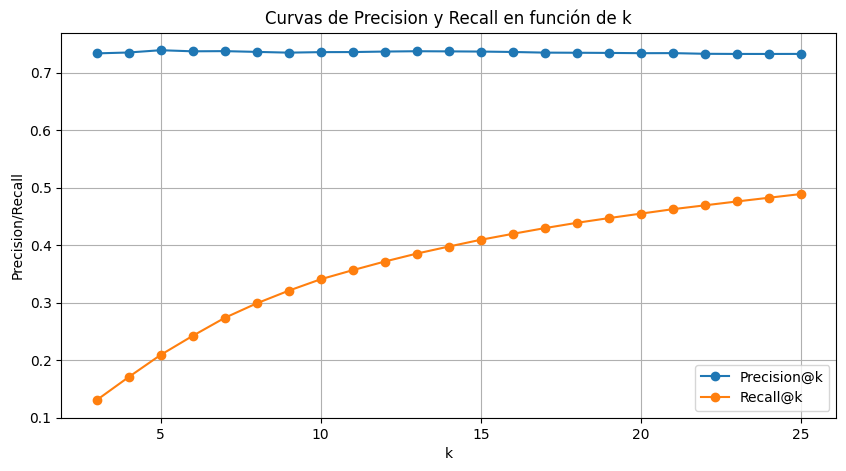

In [ ]:
#4.
# Listas para almacenar los valores de precision y recall
precisiones = []
recalls = []
ks = list(range(3, 26))

# Calcular precision@k y recall@k para k entre 3 y 25
for k in ks:
    precisiones_k, recalls_k = precision_recall_at_k(predicciones_svd, k=k, threshold=3.5)
    precision_promedio = sum(precisiones_k.values()) / len(precisiones_k)
    recall_promedio = sum(recalls_k.values()) / len(recalls_k)

    precisiones.append(precision_promedio)
    recalls.append(recall_promedio)

# Graficar las curvas

plt.figure(figsize=(10, 5))
plt.plot(ks, precisiones, label='Precision@k', marker='o')
plt.plot(ks, recalls, label='Recall@k', marker='o')
plt.xlabel('k')
plt.ylabel('Precision/Recall')
plt.title('Curvas de Precision y Recall en función de k')
plt.legend()
plt.grid()
plt.show()


El modelo presenta una buena precision, ya que se mantiene estable alrededor del 70%. En cuanto al Recall, este  mejora a medida que aumentamos k, lo cual es esperado ya que estamos recomendando cada vez mas cervezas y por tanto, es mas probable que se recuperen mas cervezas relevantes, incrementando así el Recall. Sin embargo, nunca se sobrepasa a 0.5 y es muy bajos para bajos k's. Esto sugiere que el modelo esta dejando fuera varias cervezas que el usuario considera relevantes.

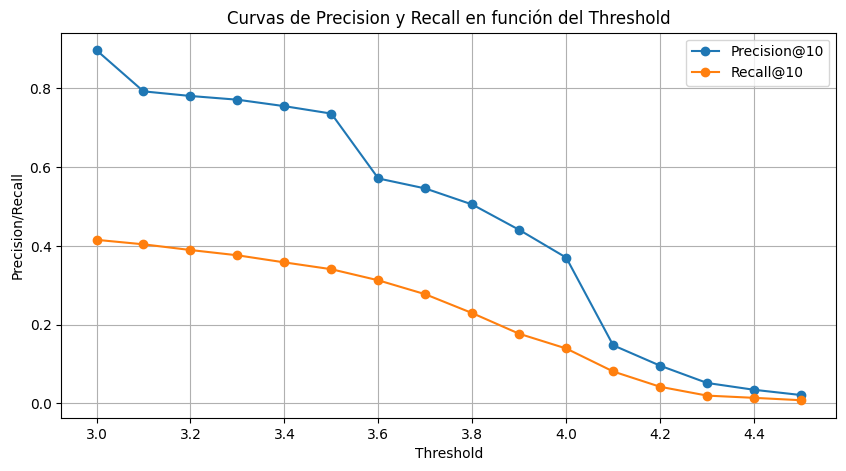

In [ ]:
#5.
# Listas para almacenar los valores de precisión y recall
precisiones_thr = []
recalls_thr = []
thresholds = [i / 10.0 for i in range(30, 46)]  # Desde 3.0 a 4.5

# Calcular precision@k y recall@k para cada threshold
for threshold in thresholds:
    precisiones_k, recalls_k = precision_recall_at_k(predicciones_svd, k=10, threshold=threshold)

    # Promediar los resultados
    precision_promedio = sum(precisiones_k.values()) / len(precisiones_k) if precisiones_k else 0
    recall_promedio = sum(recalls_k.values()) / len(recalls_k) if recalls_k else 0

    precisiones_thr.append(precision_promedio)
    recalls_thr.append(recall_promedio)

# Graficar las curvas
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisiones_thr, label='Precision@10', marker='o')
plt.plot(thresholds, recalls_thr, label='Recall@10', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')
plt.title('Curvas de Precision y Recall en función del Threshold')
plt.legend()
plt.grid()
plt.show()


Podemos ver que a medida que aumentamos el threshold tanto la precision como el recall disminuyen.

Para el caso e la precision, esto tiene sentido porque, al elevar el threshold, las predicciones tienen que tener ratinf mas altos para que la cerveza sea considerada relevante. Esto reduce la cantidad de recomendaciones consideradas correctas, ya que ahora somos mas estrictos al recomendar.

Para el Recall, al aumentar el threshold  estamos dejando de capturar muchas cervezas que en realidad podrian ser relevantes para el usuario, pero que tenian un rating mas bajo en las predicciones. Por tanto, el sistema de recomendación omite más cervezas que deberían haber sido consideradas relevantes.

In [ ]:
#6.
# Crear una lista de todas las posibles predicciones (combinaciones de usuarios y cervezas)
todos_usuarios = df_cervezas['userId'].unique()
todos_productos = df_cervezas['beerName'].unique()

# Realizar predicciones para todas las combinaciones
predicciones_faltantes = []
for uid in todos_usuarios:
    for iid in todos_productos:
        pred = svd_model.predict(uid, iid, verbose=False)
        predicciones_faltantes.append(pred)

# Convertir las predicciones a un DataFrame (usuario, producto, rating predicho)
matriz_completa = pd.DataFrame([(pred.uid, pred.iid, pred.est) for pred in predicciones_faltantes],
                               columns=['userId', 'beerName', 'rating_predicho'])

# Pivotar la tabla para obtener la matriz usuario-producto sin valores nulos
matriz_completa_pivot = matriz_completa.pivot(index='userId', columns='beerName', values='rating_predicho')

# Mostrar los primeros resultados
matriz_completa_pivot.head()

beerName,"""Shabadoo"" Black & Tan Ale",# 100,#9,'t Gaverhopke Extra,'t Smisje Calva Reserva,(512) Pecan Porter,10 Commandments,10 Squared Fish Tale Ale,10.0,1000 IBU,...,Žatec,§ucaba (Abacus),Édition 2005,Éphémère (Apple),Éphémère (Cassis / Black Currant),Éphémère (Cranberry),Équinoxe Du Printemps,Ølfabrikken Porter,Über Pils,ÜberSun (Imperial Summer Wheat Beer)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.963812,3.751571,3.838061,3.839077,3.772698,3.989360,3.689120,3.807268,3.699372,3.755489,...,3.787161,4.032098,3.755827,3.555150,3.657856,3.652659,3.710891,3.975916,3.920255,3.963875
3,3.686326,3.560155,3.520823,3.602494,3.665649,3.753035,3.504063,3.593005,3.550422,3.499988,...,3.571834,3.772476,3.641083,3.340543,3.401335,3.434016,3.577573,3.705264,3.737571,3.766899
4,4.083260,3.954268,3.911385,3.990751,4.062314,4.177635,3.892717,4.031134,3.934860,3.874643,...,3.974292,4.233886,3.992863,3.752281,3.825302,3.787579,3.983874,4.154792,4.133565,4.103209
5,3.924308,3.809182,3.663612,3.760561,3.904134,3.965041,3.714282,3.854613,3.847532,3.566588,...,3.752522,3.910446,3.901975,3.523115,3.523647,3.520766,3.717955,3.880716,3.848595,3.933558
6,4.067501,3.850820,3.834137,3.758068,3.879656,4.100815,3.939141,4.022003,3.943416,3.841704,...,3.825677,4.134667,3.945619,3.625429,3.758063,3.712768,3.768559,3.930299,4.113364,4.153728


In [ ]:
matriz_completa_pivot.isna().sum().sum()

0

In [ ]:
matriz_completa_pivot.shape

(706, 3689)

In [ ]:
assert matriz_completa_pivot.shape == user_product_matrix

Las dimensiones de la matrix concuerdad con el numero estimado de predicciones totales 😀.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por el foro de U-cursos o por correo.

<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
